In [1]:
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

c:\alabs\RAG_Agentic\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Asus ROG\AppData\Local\Temp\ipykernel_19968\2043369587.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
os.environ['OPENAI_API_KEY']=os.getenv('OPENAI_API_KEY')

## Initialize model and embeddings
llm=ChatOpenAI(model='gpt-4.1-mini',temperature=0)
embeddings = OpenAIEmbeddings()



In [4]:
llm

ChatOpenAI(output_version=None, profile={'name': 'GPT-4.1 mini', 'release_date': '2025-04-14', 'last_updated': '2025-04-14', 'open_weights': False, 'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000025562F6D550>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000025562F6DFD0>, root_client=<openai.OpenAI object at 0x000002556275CC20>, root_async_client=<openai.AsyncOpenAI object at 0x0000025562F6DD30>, model_name='gpt-4.1-mini', temperature=0.

### State Definition

In [5]:
class AgentState(TypedDict):
    question:str
    documents:List[Document]
    answer:str
    needs_retrieval:bool
    retrieval_success: bool

sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.",
    "RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.",
    "Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.",
    "Agentic systems are AI systems that can take actions, make decisions, and interact with their environment autonomously. They often use planning and reasoning capabilities."
]

documents=[Document(page_content=text)for text in sample_texts]

###create vector store
vector_store=FAISS.from_documents(documents,embeddings)
retriever=vector_store.as_retriever(k=3)

In [6]:
### PDF loader
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader

pdf_dir = Path("../data")

documents = []

for pdf_file in pdf_dir.glob("**/*.pdf"):
    loader = PyPDFLoader(str(pdf_file))
    documents.extend(loader.load())

print(f"Loaded {len(documents)} pages")

Loaded 76 pages


In [7]:
### Chunking docs
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

print(f"Created {len(chunks)} chunks")

Created 1122 chunks


In [8]:
###create vector store
vector_store=FAISS.from_documents(chunks,embeddings)
retriever=vector_store.as_retriever(k=3)

### Agents Function

In [9]:
###Decision node
def decide_retrieval(state:AgentState)->AgentState:
    """Decide if we need to retrieve documents for the question"""
    question=state["question"]

    # Simple heuristic: if question contains certain keywords, retrieve
    retrieval_keywords = ["what", "how", "explain", "describe", "tell me"]
    needs_retrieval=any(keyword in question.lower() for keyword in retrieval_keywords )
    return {**state,"needs_retrieval":needs_retrieval}

In [10]:
###Conditional logic on retrieval
def should_retrieve(state:AgentState)-> str:
    """
    Determine the next step based on retrieval decision.
    
    """
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

In [11]:
###Retrieving documents
def retrieve_documents(state:AgentState)->AgentState:
    """
    Retrieve relevant documents based on the question
    
    """
    question=state["question"]
    documents=retriever.invoke(question)
    return{**state,"documents":documents}


In [12]:
### Grading the retrieved documents
def grade_documents(state):

    question = state["question"].lower()
    docs = state["documents"]

    relevant_docs = []

    for doc in docs:
        content = doc.page_content.lower()

        if any(word in content for word in question.split()):
            relevant_docs.append(doc)

    return {
        **state,
        "relevant_docs": relevant_docs
    }

In [25]:
### Query Rewrite 
def rewrite_question(state):

    question = state["question"]
    prompt= f"""Rewrite the following question to improve retrieval:

                Question: {question}

                Rewritten Question:"""

    response = llm.invoke(prompt)

    return {
        **state,
        "question": response.content,
        "retry_count": state.get("retry_count", 0) + 1
    }

In [26]:
def should_retry(state: AgentState):

    if state.get("relevant_docs", []):
        return "generate"

    if state.get("retry_count", 0) >= 2:
        return "generate"

    return "rewrite"

In [27]:
def generate_answer(state:AgentState)->AgentState:
    """Generate answer based on the retrieved documents"""

    question=state["question"]
    documents=state.get("documents",[])

    if documents:
        # RAG approach: use documents as context
        context = "\n\n".join([doc.page_content for doc in documents])
        prompt=f"""Based on the following context answer the question:

        Context : {context}
        Question : {question}
        Answer:"""

    else:

        prompt=f"Answer the following question:{question}"
    response=llm.invoke(prompt)
    answer=response.content

    return{**state,"answer":answer}


### Creating the graph

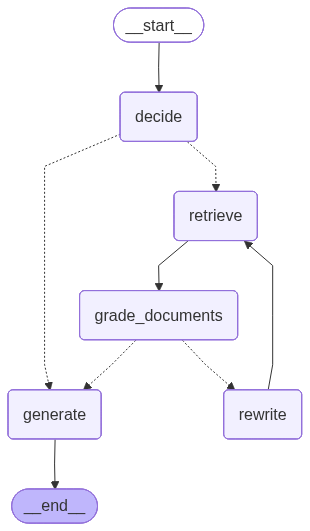

In [28]:
#Create the state graph
workflow= StateGraph(AgentState)

## Add nodes
workflow.add_node(
    "decide",
    decide_retrieval
)

workflow.add_node(
    "retrieve",
    retrieve_documents
)

workflow.add_node(
    "grade_documents",
    grade_documents
)

workflow.add_node(
    "rewrite",
    rewrite_question
)

workflow.add_node(
    "generate",
    generate_answer
)

# Set entry point
workflow.set_entry_point("decide")

##Add conditional edge to retrieve
workflow.add_conditional_edges(
    "decide",
      should_retrieve,
        {"retrieve":"retrieve",
         "generate":"generate"}  )

### Adding first edge
workflow.add_edge(
    "retrieve",
    "grade_documents"
)

### Add Conditional edge to retry
workflow.add_conditional_edges(
    "grade_documents",
    should_retry,
    {
        "generate": "generate",
        "rewrite": "rewrite"
    }
)

## Add edges
workflow.add_edge(
    "rewrite",
    "retrieve"
)
workflow.add_edge(
    "generate",
    END
)

##Compile the graph
app=workflow.compile()
app



####  Test the Agent

In [1]:
def ask_question(question:str):
    """
    Helps the user to ask any question

    """
    initial_state = {
        "question": question,
        "documents": [],
        "relevant_docs": [],  
        "needs_retrieval": False,
        "answer": "",
        "retry_count": 0       
    }

    result = app.invoke(initial_state)
    return result


In [ ]:
# Test with another question
question2 = "How does DNA sequencing work?"
result2 = ask_question(question2)

print(f"Question: {question2}")
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "="*100 + "\n")

Question: How does DNA sequencing work?
Retrieved documents: 4
Answer: DNA sequencing is the process of determining the precise order of nucleotides (adenine, thymine, cytosine, and guanine) within a DNA molecule. Although the provided context primarily focuses on recombinant DNA technology and its applications, the general principle of DNA sequencing involves several key steps:

1. **DNA Fragmentation:** The DNA to be sequenced is first broken into smaller fragments to facilitate analysis.

2. **Amplification:** These fragments are often amplified using techniques like PCR (polymerase chain reaction) to generate sufficient quantities for sequencing.

3. **Sequencing Reaction:** Using enzymes such as DNA polymerase, the DNA fragments are copied in the presence of normal nucleotides and specially modified nucleotides (e.g., dideoxynucleotides in Sanger sequencing) that terminate DNA strand elongation at specific bases.

4. **Detection:** The terminated fragments are then separated by si

In [ ]:
# Test with question outside the scope of the document
question2 = "How does ornithology help in bird-friendly learning?"
result2 = ask_question(question2)

print(f"Question: {question2}")
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "="*100 + "\n")

Question: How does ornithology help in bird-friendly learning?
Retrieved documents: 4
Answer: The provided context does not contain information related to ornithology or bird-friendly learning. Therefore, based on the given text, it is not possible to explain how ornithology helps in bird-friendly learning.


